1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import trapezoid as trapz

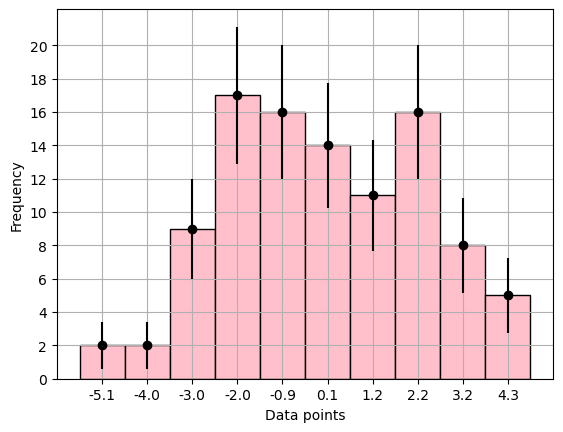

In [17]:
#a
np.random.seed(123)
N=100
x = np.random.normal(0, 2.0, N)

#b
bins_number = int(np.sqrt(N))

counts, bin_edges, dontknowdontcare = plt.hist(x, bins_number, color='pink', edgecolor='black')
errors = np.sqrt(counts)
bin_centers = [(a+b)/2 for a,b in zip(bin_edges[:-1], bin_edges[1:])]

plt.errorbar(bin_centers, counts, errors, fmt='o', color='black')

plt.xlabel("Data points")
plt.ylabel("Frequency")

ax = plt.gca()  
ax.set_xticks(bin_centers)
ax.set_xticklabels( [f'{x:.1f}' for x in bin_centers] )
ax.set_yticks(np.arange(0,max(counts)+5,2))

plt.grid()

In [18]:
#c
std_default = 1.06*x.std()*x.size**(-1/5)
x_grid = np.linspace(x.min() - 3*std_default, x.max() + 3*std_default, 1000)
gaussians = []

for element in x:
    g = stats.norm.pdf(x_grid, loc=element, scale=std_default)
    gaussians.append(g)

#e
kde = np.sum(gaussians, axis=0) #suma sobre las columnas (sobre cada x)
area_kde = trapz(kde, x_grid)
area_hist = np.sum(counts)
kde = kde * area_hist/area_kde

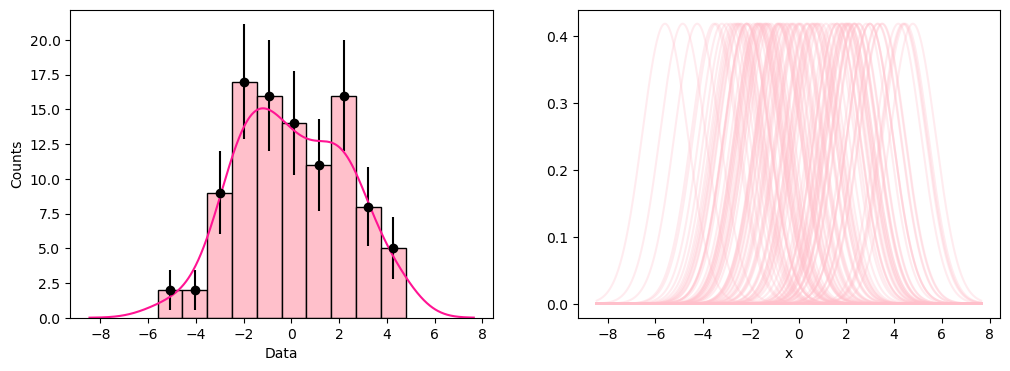

In [19]:
#d

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(x, bins=10, color='pink', edgecolor='black')
ax[0].errorbar(bin_centers, counts, errors, fmt='o', color='black')
ax[0].plot(x_grid, kde, color='deeppink')
ax[0].set_xlabel("Data")
ax[0].set_ylabel("Counts")

gaussians = np.array(gaussians)    
ax[1].plot(x_grid, gaussians.T, color='pink', alpha=0.3)
ax[1].set_xlabel("x")

plt.show()

2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

In [5]:
# ! wget https://www.dropbox.com/s/u4y3k4kk5btc7j46/two_categories_scatter_plot.png
# from IPython.display import Image
# Image('two_categories_scatter_plot.png')

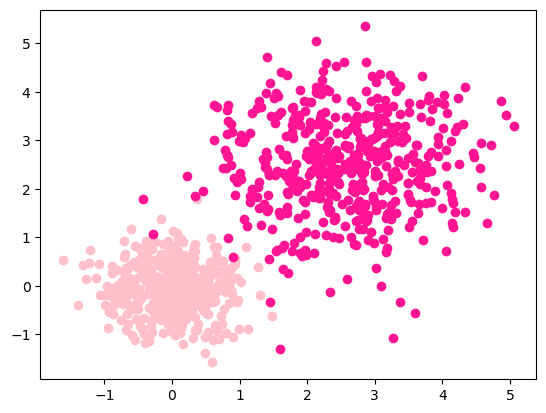

In [6]:
def dataset_generator(mean1, mean2, std1, std2, N):
    x1 = np.random.normal(mean1,std1,N)
    y1 = np.random.normal(mean1,std1,N)
    x2 = np.random.normal(mean2,std2,N)
    y2 = np.random.normal(mean2,std2,N)
    return x1, y1, x2, y2

mean1 = 0.0
mean2 = 2.5
std1 = 0.5
std2 = 1.0
N = 500

x1, y1, x2, y2 = dataset_generator(mean1, mean2, std1, std2, N)
plt.scatter(x1, y1, color='pink')
plt.scatter(x2, y2, color='deeppink')
plt.show()

3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

In [7]:
# %%bash

# cd /home/gaby/Documents/PoD/CP/LaboratoryOfComputationalPhysics_Y8
# wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy

In [8]:
import pandas as pd

In [9]:
file = np.load('residuals_261.npy', allow_pickle=True)
df = pd.DataFrame(file.item())
df

,residuals,distances
0,1.100000,16.0
1,-1.950000,6.3
2,-7.200000,3.4
3,-4.150000,8.4
4,-6.590000,1.7
...,...,...
11126,-0.760000,14.4
11127,0.380000,7.5
11128,0.083333,1.7
11129,0.166667,19.1


In [10]:
# Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
clean_df = df[np.abs(df['residuals'])<2.0]

In [11]:
# perform a linear regression of "residuals" versus "distances" using scipy.stats.linregress()
import scipy
regression = scipy.stats.linregress(clean_df['distances'],clean_df['residuals'])

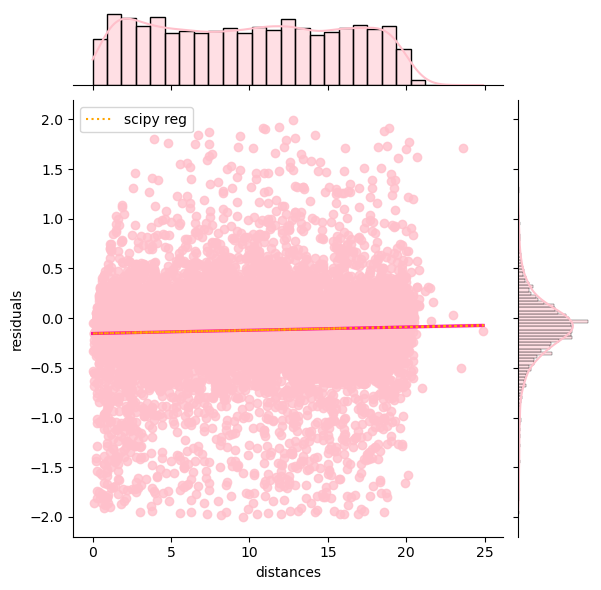

In [12]:
# plot a seaborn jointplot of "residuals" versus "distances", having seaborn performing a linear regression.
# The result of the regression should be displayed on the plot

import seaborn
g = seaborn.jointplot(data=clean_df, x=clean_df['distances'], y=clean_df['residuals'], kind='reg', color='pink', line_kws={'color': 'deeppink'})
g.ax_joint.plot(clean_df['distances'], regression.slope*clean_df['distances'] + regression.intercept, color='orange', ls='dotted', label='scipy reg')
plt.legend()